# Bài tập: YOLOv8 From Scratch bằng PyTorch

Tự xây dựng YOLOv8n cho bài toán object detection, từ các block cơ bản đến pipeline train, inference và evaluation. Trọng tâm là hiểu luồng tensor qua `Backbone → Neck → Detection Head`, cơ chế anchor-free và Distribution Focal Loss (DFL).

**Quy trình:** đọc tổng quan, kiểm tra từng cell `TODO`, chạy shape test, kiểm tra loss + backward, sau đó train và đánh giá trên dataset theo định dạng YOLO.

## 1. Setup


In [1]:
# Nếu môi trường đã có đủ package, pip sẽ bỏ qua phần lớn quá trình cài đặt.
# Bỏ comment nếu cần, nhưng khi nộp cần comment lại để tránh syntax error.
# %pip install -q torch torchvision matplotlib pandas pillow tqdm pyyaml


In [2]:
import math
import random
import shutil
import time
import urllib.error
import urllib.request
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import yaml
from PIL import Image, ImageDraw
from torch.utils.data import DataLoader, Dataset
from torchvision.ops import batched_nms, box_iou
from torchvision.transforms import functional as TF
from tqdm.auto import tqdm


In [3]:
# =========================================================
# CẤU HÌNH
# =========================================================
IN_COLAB = "COLAB_RELEASE_TAG" in __import__("os").environ
IN_KAGGLE = Path("/kaggle/working").exists()

if IN_COLAB:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        DATA_ROOT = Path("/content/drive/MyDrive/datasets/road_damage_pcm")
    except (ImportError, RuntimeError):
        DATA_ROOT = Path("/content/data/road_damage_pcm")
elif IN_KAGGLE:
    DATA_ROOT = Path("/kaggle/working/datasets/road_damage_pcm")
else:
    DATA_ROOT = Path("./data/road_damage_pcm")

IMAGE_SIZE = 640
BATCH_SIZE = 8
NUM_CLASSES = 3
CLASS_NAMES = ["Pothole", "Crack", "Manhole"]
# 25 epochs đủ để quan sát mô hình học và bắt đầu overfit trên dataset này.
NUM_EPOCHS = 25
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 5e-4
NUM_WORKERS = 0
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AUTO_DOWNLOAD_DATASET = True

# YOLOv8 dùng 16 bins DFL và dự đoán tại ba stride.
REG_MAX = 16
STRIDES = (8, 16, 32)
BOX_GAIN, CLS_GAIN, DFL_GAIN = 7.5, 0.5, 1.5

assert IMAGE_SIZE % 32 == 0, "IMAGE_SIZE phải chia hết cho 32."


Mounted at /content/drive


In [4]:
# Cố định seed để kết quả dễ tái lập.
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(SEED)
print(f"Device: {DEVICE}")
print(f"Data root: {DATA_ROOT.resolve() if not IN_COLAB and not IN_KAGGLE else DATA_ROOT}")


Device: cuda
Data root: /content/drive/MyDrive/datasets/road_damage_pcm


## 2. Tải và chuẩn hóa dataset tự động

Notebook sử dụng [Road Damage Dataset: Potholes, Cracks and Manholes](https://www.kaggle.com/datasets/lorenzoarcioni/road-damage-dataset-potholes-cracks-and-manholes), gồm 2.009 ảnh và ba lớp `Pothole`, `Crack`, `Manhole`.

Archive gốc chỉ có một thư mục ảnh, chưa chia train/validation. Cell bên dưới sẽ:

1. tải archive công khai từ Kaggle nếu cache chưa tồn tại;
2. chọn `labels-YOLO/` thay vì polygon labels trong `labels/`;
3. chia train/validation theo tỷ lệ 80/20 với `SEED` cố định;
4. tạo cấu trúc `train/valid/images/labels` và `data.yaml`;
5. bỏ qua tải và chuẩn hóa nếu dataset đã sẵn sàng.


In [5]:
# =========================================================
# TẢI VÀ CHUẨN HÓA ROAD DAMAGE DATASET
# =========================================================
DATASET_URL = (
    "https://www.kaggle.com/api/v1/datasets/download/"
    "lorenzoarcioni/road-damage-dataset-potholes-cracks-and-manholes"
)
DATASET_ARCHIVE = DATA_ROOT.parent / "road_damage_pcm.zip"


def prepare_road_damage_dataset(data_root=DATA_ROOT):
    """Tải, chia 80/20 và đưa dataset về cấu trúc YOLO train/valid."""
    ready_file = data_root / ".ready"
    if ready_file.exists():
        print(f"Dataset đã sẵn sàng tại: {data_root}")
        return

    DATASET_ARCHIVE.parent.mkdir(parents=True, exist_ok=True)
    if not DATASET_ARCHIVE.exists() or not zipfile.is_zipfile(DATASET_ARCHIVE):
        print("Đang tải Road Damage Dataset (~195 MB)...")
        urllib.request.urlretrieve(DATASET_URL, DATASET_ARCHIVE)

    image_prefix = "data/images/"
    label_prefix = "data/labels-YOLO/"
    image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

    with zipfile.ZipFile(DATASET_ARCHIVE) as archive:
        names = archive.namelist()
        labels = set(name for name in names if name.startswith(label_prefix))
        pairs = []
        for image_name in names:
            if not image_name.startswith(image_prefix) or Path(image_name).suffix.lower() not in image_exts:
                continue
            label_name = f"{label_prefix}{Path(image_name).stem}.txt"
            if label_name in labels:
                pairs.append((image_name, label_name))

        random.Random(SEED).shuffle(pairs)
        split_index = int(0.8 * len(pairs))
        for index, (image_name, label_name) in enumerate(tqdm(pairs, desc="Chuẩn hóa dataset")):
            split = "train" if index < split_index else "valid"
            for member, folder in ((image_name, "images"), (label_name, "labels")):
                destination = data_root / split / folder / Path(member).name
                destination.parent.mkdir(parents=True, exist_ok=True)
                with archive.open(member) as source, destination.open("wb") as target:
                    shutil.copyfileobj(source, target)

    data_yaml = {
        "path": str(data_root.resolve()),
        "train": "train/images",
        "val": "valid/images",
        "names": CLASS_NAMES,
    }
    with (data_root / "data.yaml").open("w", encoding="utf-8") as file:
        yaml.safe_dump(data_yaml, file, sort_keys=False, allow_unicode=True)
    ready_file.write_text(str(len(pairs)), encoding="utf-8")
    print(f"Hoàn tất: {split_index} train | {len(pairs) - split_index} validation")


if AUTO_DOWNLOAD_DATASET:
    try:
        prepare_road_damage_dataset()
    except (OSError, urllib.error.URLError, zipfile.BadZipFile) as error:
        print("Không thể tải dataset:", error)
        print("Shape test và loss test vẫn chạy được mà không cần dataset.")


Đang tải Road Damage Dataset (~195 MB)...


Chuẩn hóa dataset:   0%|          | 0/2009 [00:00<?, ?it/s]

Hoàn tất: 1607 train | 402 validation


## 3. Dataset và preprocessing

Mỗi dòng label có dạng `class_id x_center y_center width height`; bốn tọa độ được chuẩn hóa về `[0, 1]`. Vì notebook resize trực tiếp ảnh về hình vuông, các tọa độ normalized vẫn giữ nguyên. Mỗi ảnh có thể có số object khác nhau, vì vậy `collate_fn` trả target dưới dạng một `list`.


In [6]:
# =========================================================
# DATASET VÀ DATALOADER
# =========================================================
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


class YOLODetectionDataset(Dataset):
    """Đọc ảnh và label YOLO normalized: class_id, x_center, y_center, width, height."""

    def __init__(self, data_root, split, image_size):
        self.image_dir = Path(data_root) / split / "images"
        self.label_dir = Path(data_root) / split / "labels"
        self.image_size = image_size
        if not self.image_dir.exists():
            raise FileNotFoundError(f"Không tìm thấy {self.image_dir}.")
        self.image_paths = sorted(
            path for path in self.image_dir.iterdir()
            if path.suffix.lower() in IMAGE_EXTENSIONS
        )

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        image_path = self.image_paths[index]
        image = Image.open(image_path).convert("RGB")
        image = TF.to_tensor(TF.resize(image, [self.image_size, self.image_size], antialias=True))

        labels, boxes = [], []
        label_path = self.label_dir / f"{image_path.stem}.txt"
        if label_path.exists():
            for line in label_path.read_text(encoding="utf-8").splitlines():
                if not line.strip():
                    continue
                class_id, x, y, width, height = line.split()
                labels.append(int(class_id))
                boxes.append([float(x), float(y), float(width), float(height)])

        target = {
            "labels": torch.tensor(labels, dtype=torch.long),
            "boxes": torch.tensor(boxes, dtype=torch.float32).reshape(-1, 4),
        }
        return image, target


def detection_collate_fn(batch):
    images, targets = zip(*batch)
    return torch.stack(images), list(targets)


def build_dataloaders():
    train_dataset = YOLODetectionDataset(DATA_ROOT, "train", IMAGE_SIZE)
    val_dataset = YOLODetectionDataset(DATA_ROOT, "valid", IMAGE_SIZE)
    options = dict(
        batch_size=BATCH_SIZE,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        collate_fn=detection_collate_fn,
    )
    train_loader = DataLoader(train_dataset, shuffle=True, **options)
    val_loader = DataLoader(val_dataset, shuffle=False, **options)
    return train_dataset, val_dataset, train_loader, val_loader


try:
    train_dataset, val_dataset, train_loader, val_loader = build_dataloaders()
    DATA_AVAILABLE = True
    print(f"Train: {len(train_dataset)} | Validation: {len(val_dataset)}")
except FileNotFoundError as error:
    DATA_AVAILABLE = False
    train_dataset = val_dataset = train_loader = val_loader = None
    print(error)
    print("Shape test và loss test vẫn chạy được mà không cần dataset.")


Train: 1607 | Validation: 402


## 4. Visualization dataset


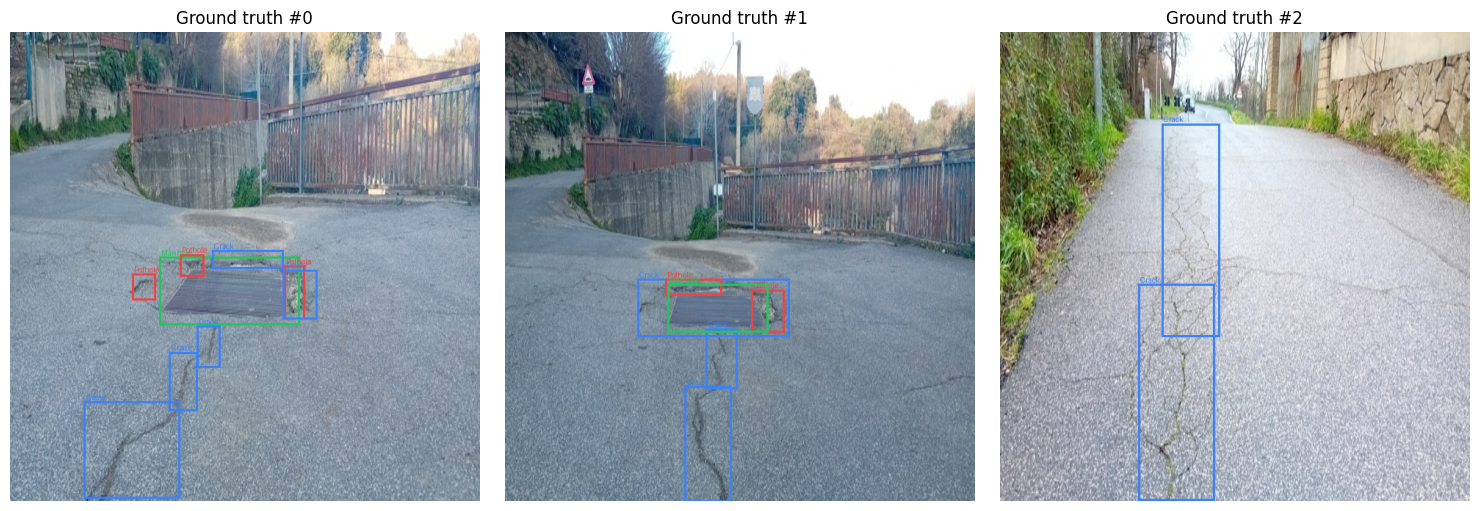

In [7]:
# =========================================================
# TRỰC QUAN HÓA DATASET
# =========================================================
BOX_COLORS = ["#ef4444", "#3b82f6", "#22c55e", "#f59e0b", "#a855f7"]


def xywhn_to_xyxy(boxes, image_size):
    """Đổi normalized xywh sang xyxy theo pixel."""
    if boxes.numel() == 0:
        return boxes.reshape(0, 4)
    x, y, w, h = boxes.unbind(-1)
    return torch.stack([
        (x - w / 2) * image_size,
        (y - h / 2) * image_size,
        (x + w / 2) * image_size,
        (y + h / 2) * image_size,
    ], dim=-1)


def draw_boxes(image, boxes, labels, scores=None, class_names=CLASS_NAMES):
    """Vẽ bbox lên Tensor ảnh [3,H,W] và trả về ảnh PIL."""
    canvas = TF.to_pil_image(image.cpu().clamp(0, 1))
    draw = ImageDraw.Draw(canvas)
    for index, (box, label) in enumerate(zip(boxes, labels)):
        color = BOX_COLORS[int(label) % len(BOX_COLORS)]
        x1, y1, x2, y2 = [float(value) for value in box]
        draw.rectangle((x1, y1, x2, y2), outline=color, width=3)
        text = class_names[int(label)]
        if scores is not None:
            text += f" {float(scores[index]):.2f}"
        draw.text((x1 + 3, max(0, y1 - 12)), text, fill=color)
    return canvas


def show_dataset_samples(dataset, count=3):
    count = min(count, len(dataset))
    fig, axes = plt.subplots(1, count, figsize=(5 * count, 5), squeeze=False)
    for index in range(count):
        image, target = dataset[index]
        boxes = xywhn_to_xyxy(target["boxes"], image.shape[-1])
        axes[0, index].imshow(draw_boxes(image, boxes, target["labels"]))
        axes[0, index].set_title(f"Ground truth #{index}")
        axes[0, index].axis("off")
    plt.tight_layout()
    plt.show()


if DATA_AVAILABLE:
    show_dataset_samples(train_dataset)
else:
    print("Bỏ qua visualization vì dataset chưa tồn tại.")


## 5. Architecture overview

```text
Input
  ↓
Backbone ── trích xuất P3 / P4 / P5
  ↓
Multi-scale Feature Fusion (FPN + PAN)
  ↓
P3 stride 8 / P4 stride 16 / P5 stride 32
  ↓
Decoupled Detection Head
  ├── Bounding Box Regression: 4 × reg_max logits (DFL)
  └── Classification: NUM_CLASSES logits
```

- **Backbone** giảm dần kích thước không gian để học feature từ chi tiết đến ngữ nghĩa.
- **Neck** truyền thông tin theo cả top-down và bottom-up để trộn feature ở nhiều scale.
- **Head** dự đoán box và class bằng hai nhánh riêng, không có objectness branch kiểu YOLOv3.
- **Anchor-free** ở đây không dùng predefined anchor boxes. Các grid point chỉ là tâm tham chiếu để biểu diễn khoảng cách `left, top, right, bottom`.
- P3 phù hợp hơn với vật nhỏ; P4 với vật vừa; P5 với vật lớn.

Notebook dùng quy mô **YOLOv8n**: depth `0.33`, width `0.25`, ba output stride `8/16/32`.


## 6. Các khối kiến trúc

### 6.1 Conv-BN-SiLU

Thứ tự `Conv2d → BatchNorm2d → SiLU` là block cơ bản xuyên suốt mô hình.

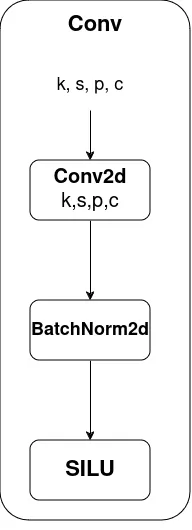


In [8]:
# =========================================================
# TODO 1: XÂY DỰNG CONV-BN-SILU
# =========================================================

def autopad(kernel_size, padding=None, dilation=1):
    """Tính padding để giữ spatial size khi stride=1."""
    # TODO: Tính effective kernel khi có dilation và trả về padding phù hợp.
    if padding is None:
        if isinstance(kernel_size, int):
            padding = (kernel_size - 1) * dilation // 2
        else:
            padding = [
                (k - 1) * dilation // 2 for k in kernel_size
            ]
    return padding


class Conv(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=1, stride=1,
                 padding=None, groups=1, dilation=1, activation=True):
        super().__init__()
        # TODO: Khởi tạo Conv2d (không bias), BatchNorm2d và SiLU/Identity.
        self.conv = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=kernel_size,
            stride=stride,
            padding=autopad(kernel_size, padding, dilation),
            groups=groups,
            dilation=dilation,
            bias=False,
        )
        self.bn = nn.BatchNorm2d(out_channels)
        self.act = (
            nn.SiLU(inplace=True)
            if activation is True
            else (
                activation
                if isinstance(activation, nn.Module)
                else nn.Identity()
            )
        )
    def forward(self, x):
        # TODO: Thực hiện Conv2d → BatchNorm2d → activation.
        return self.act(self.bn(self.conv(x)))


In [9]:
conv_test = Conv(3, 16, kernel_size=3, stride=2)
conv_y = conv_test(torch.randn(2, 3, 64, 64))
assert conv_y.shape == (2, 16, 32, 32), f"Conv sai shape: {conv_y.shape}"
print("Conv output:", conv_y.shape)


Conv output: torch.Size([2, 16, 32, 32])


### 6.2 Bottleneck

Hai convolution tinh chỉnh feature. Shortcut chỉ được cộng khi số channel đầu vào và đầu ra bằng nhau.

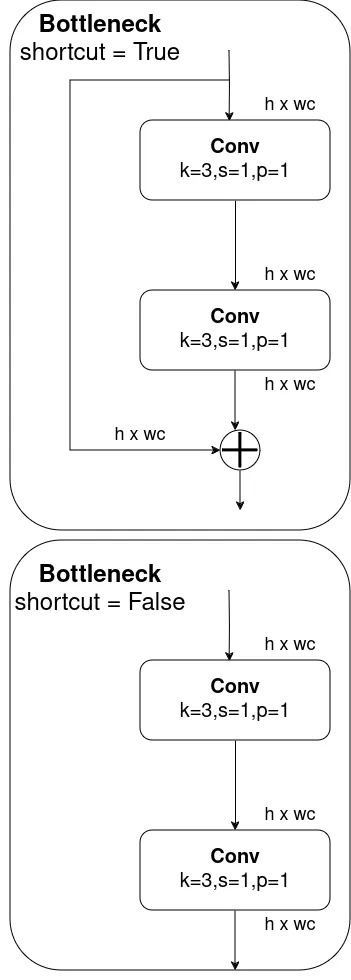


In [10]:
# =========================================================
# TODO 2: XÂY DỰNG BOTTLENECK
# =========================================================

class Bottleneck(nn.Module):
    def __init__(self, in_channels, out_channels, shortcut=True, expansion=0.5):
        super().__init__()
        # TODO: Tạo hai lớp Conv và xác định khi nào được dùng shortcut.
        hidden_channels = int(out_channels * expansion)
        self.cv1 = Conv(in_channels, hidden_channels, kernel_size=3, stride=1)
        self.cv2 = Conv(hidden_channels, out_channels, kernel_size=3, stride=1)
        self.add = shortcut and in_channels == out_channels

    def forward(self, x):
        # TODO: Forward qua hai Conv và cộng shortcut khi phù hợp.
       return x + self.cv2(self.cv1(x)) if self.add else self.cv2(self.cv1(x))

### 6.3 C2f

C2f đưa input qua convolution 1×1 rồi chia feature thành hai nhánh. Một nhánh được giữ lại; nhánh còn lại lần lượt đi qua các Bottleneck. Các feature được nối theo chiều channel trước convolution cuối.

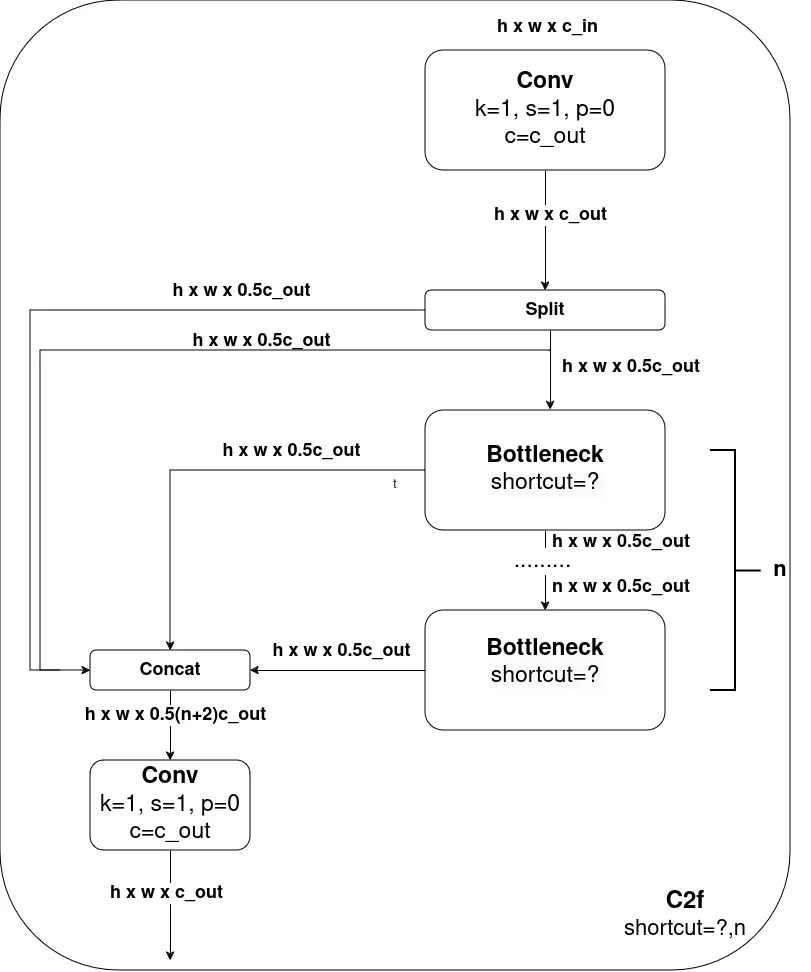


In [11]:
# =========================================================
# TODO 3: XÂY DỰNG C2F
# =========================================================

class C2f(nn.Module):
    def __init__(self, in_channels, out_channels, repeats=1, shortcut=False, expansion=0.5):
        super().__init__()
        # TODO: Tạo convolution đầu, chuỗi Bottleneck và convolution cuối.
        self.hidden_channels = int(out_channels * expansion)
        self.cv1 = Conv(in_channels, 2 * self.hidden_channels, 1, 1)
        self.cv2 = Conv(
            (2 + repeats) * self.hidden_channels, out_channels, 1, 1
        )
        self.m = nn.ModuleList(
            Bottleneck(
                self.hidden_channels,
                self.hidden_channels,
                shortcut=shortcut,
                expansion=1.0,
            )
            for _ in range(repeats)
        )
    def forward(self, x):
        # TODO: Chia feature thành hai nhánh, chạy Bottleneck tuần tự,
        # concatenate theo chiều channel rồi đưa qua convolution cuối.
        y = list(self.cv1(x).chunk(2, dim=1))
        for layer in self.m:
            y.append(layer(y[-1]))
        return self.cv2(torch.cat(y, dim=1))

In [12]:
c2f_test = C2f(64, 64, repeats=2, shortcut=True)
c2f_y = c2f_test(torch.randn(2, 64, 40, 40))
assert c2f_y.shape == (2, 64, 40, 40), f"C2f sai shape: {c2f_y.shape}"
print("C2f output:", c2f_y.shape)


C2f output: torch.Size([2, 64, 40, 40])


### 6.4 SPPF

SPPF áp dụng cùng một MaxPool 5×5 **nối tiếp ba lần**. Ba lần pooling tương đương receptive field lớn dần nhưng rẻ hơn ba kernel lớn chạy song song. Feature trước pooling và sau từng lần pooling được concatenate.


In [13]:
# =========================================================
# TODO 4: XÂY DỰNG SPPF
# =========================================================

class SPPF(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=5):
        super().__init__()
        # TODO: Tạo hai lớp Conv và một MaxPool dùng lặp lại ba lần.
        hidden_channels = in_channels // 2
        self.cv1 = Conv(in_channels, hidden_channels, 1, 1)
        self.cv2 = Conv(hidden_channels * 4, out_channels, 1, 1)
        self.m = nn.MaxPool2d(
            kernel_size=kernel_size, stride=1, padding=kernel_size // 2
        )
    def forward(self, x):
        # TODO: Pooling nối tiếp ba lần, concatenate bốn feature rồi fuse.
        x = self.cv1(x)
        y1 = self.m(x)
        y2 = self.m(y1)
        y3 = self.m(y2)
        return self.cv2(torch.cat([x, y1, y2, y3], dim=1))

## 7. Backbone, Neck và Detection Head

Notebook cố định cấu hình YOLOv8n với channel `16, 32, 64, 128, 256` để code ngắn và dễ theo dõi.


In [14]:
# =========================================================
# TODO 5: XÂY DỰNG BACKBONE
# =========================================================

class YOLOv8Backbone(nn.Module):
    """Backbone YOLOv8n trả về feature P3, P4, P5."""

    def __init__(self):
        super().__init__()
        # Cấu hình YOLOv8n dùng channel 16, 32, 64, 128, 256.
        # TODO: Xây dựng các stage Conv/C2f và SPPF.
        # TODO: Khai báo self.out_channels cho P3, P4, P5.
        # Stem -> P1/2 (16)
        self.stem = Conv(3, 16, 3, 2)

        # Stage 1 -> P2/4 (32)
        self.stage1_conv = Conv(16, 32, 3, 2)
        self.stage1_c2f = C2f(32, 32, repeats=1, shortcut=True)

        # Stage 2 -> P3/8 (64)
        self.stage2_conv = Conv(32, 64, 3, 2)
        self.stage2_c2f = C2f(64, 64, repeats=2, shortcut=True)

        # Stage 3 -> P4/16 (128)
        self.stage3_conv = Conv(64, 128, 3, 2)
        self.stage3_c2f = C2f(128, 128, repeats=2, shortcut=True)

        # Stage 4 -> P5/32 (256)
        self.stage4_conv = Conv(128, 256, 3, 2)
        self.stage4_c2f = C2f(256, 256, repeats=1, shortcut=True)
        self.sppf = SPPF(256, 256, kernel_size=5)

        self.out_channels = (64, 128, 256)

    def forward(self, x):
        # TODO: Trích xuất và trả về bộ ba (p3, p4, p5) có stride 8, 16, 32.
        x = self.stem(x)
        x = self.stage1_c2f(self.stage1_conv(x))

        p3 = self.stage2_c2f(self.stage2_conv(x))  # Stride 8,  Channels: 64
        p4 = self.stage3_c2f(self.stage3_conv(p3))  # Stride 16, Channels: 128
        p5 = self.sppf(
            self.stage4_c2f(self.stage4_conv(p4))
        )  # Stride 32, Channels: 256

        return p3, p4, p5


In [15]:
# =========================================================
# TODO 6: XÂY DỰNG MULTI-SCALE FEATURE FUSION / NECK
# =========================================================

class YOLOv8Neck(nn.Module):
    """FPN top-down kết hợp PAN bottom-up, trả về P3/P4/P5 đã fusion."""

    def __init__(self, channels):
        super().__init__()
        # TODO: Xây dựng nhánh top-down và bottom-up bằng C2f, Conv và upsample.
        # TODO: Khai báo self.out_channels cho ba feature đầu ra.
        c3, c4, c5 = channels  # 64, 128, 256

        # Top-down pathway (FPN)
        self.c2f_up4 = C2f(c5 + c4, c4, repeats=1, shortcut=False)  # 256+128 -> 128
        self.c2f_up3 = C2f(c4 + c3, c3, repeats=1, shortcut=False)  # 128+64 -> 64

        # Bottom-up pathway (PAN)
        self.conv_down3 = Conv(c3, c3, 3, 2)  # Stride 2 downsample -> 64
        self.c2f_down4 = C2f(
            c3 + c4, c4, repeats=1, shortcut=False
        )  # 64+128 -> 128
        self.conv_down4 = Conv(c4, c4, 3, 2)  # Stride 2 downsample -> 128
        self.c2f_down5 = C2f(
            c4 + c5, c5, repeats=1, shortcut=False
        )  # 128+256 -> 256

        self.out_channels = (c3, c4, c5)

    def forward(self, features):
        # TODO: Fusion bộ ba (p3, p4, p5) và trả về ba scale sau fusion.
        p3_in, p4_in, p5_in = features

        # Top-down FPN
        p5_up = F.interpolate(p5_in, scale_factor=2, mode="nearest")
        p4_up = self.c2f_up4(torch.cat([p5_up, p4_in], dim=1))

        p4_up_up = F.interpolate(p4_up, scale_factor=2, mode="nearest")
        p3_out = self.c2f_up3(torch.cat([p4_up_up, p3_in], dim=1))

        # Bottom-up PAN
        p3_down = self.conv_down3(p3_out)
        p4_out = self.c2f_down4(torch.cat([p3_down, p4_up], dim=1))

        p4_down = self.conv_down4(p4_out)
        p5_out = self.c2f_down5(torch.cat([p4_down, p5_in], dim=1))

        return p3_out, p4_out, p5_out


In [16]:
# =========================================================
# TODO 7: XÂY DỰNG ANCHOR-FREE DETECTION HEAD
# =========================================================

class DetectionHead(nn.Module):
    """Decoupled head: mỗi scale có nhánh bbox DFL và nhánh classification riêng."""

    def __init__(self, channels, num_classes, reg_max=16):
        super().__init__()
        # TODO: Lưu cấu hình và tạo box/class branch riêng cho mỗi scale.
        # Bbox branch phải xuất 4 * reg_max channel; class branch xuất num_classes.
        self.num_classes = num_classes
        self.reg_max = reg_max

        self.box_branches = nn.ModuleList([
            nn.Sequential(
                Conv(c, c, 3, 1), Conv(c, c, 3, 1), nn.Conv2d(c, 4 * reg_max, 1)
            )
            for c in channels
        ])

        self.cls_branches = nn.ModuleList([
            nn.Sequential(
                Conv(c, c, 3, 1), Conv(c, c, 3, 1), nn.Conv2d(c, num_classes, 1)
            )
            for c in channels
        ])
    def forward(self, features):
        # TODO: Trả về list (bbox_logits, class_logits) cho P3, P4 và P5.
        outputs = []
        for i, feat in enumerate(features):
            bbox_logits = self.box_branches[i](feat)
            class_logits = self.cls_branches[i](feat)
            outputs.append((bbox_logits, class_logits))
        return outputs


In [17]:
# =========================================================
# TODO 8: GHÉP MÔ HÌNH YOLOV8 HOÀN CHỈNH
# =========================================================

class YOLOv8(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, reg_max=REG_MAX):
        super().__init__()
        # TODO: Khởi tạo Backbone, Neck và Detection Head.
        self.backbone = YOLOv8Backbone()
        self.neck = YOLOv8Neck(self.backbone.out_channels)
        self.head = DetectionHead(self.neck.out_channels, num_classes, reg_max)

    def forward(self, x):
        # TODO: Thực hiện luồng Backbone → Neck → Detection Head.
        backbone_feats = self.backbone(x)
        neck_feats = self.neck(backbone_feats)
        return self.head(neck_feats)

## 8. Quick shape test

Cell này không cần dataset. Shape test sử dụng input `IMAGE_SIZE × IMAGE_SIZE`. Với `IMAGE_SIZE = 640`, P3/P4/P5 lần lượt có kích thước 80×80, 40×40 và 20×20, tương ứng với stride 8, 16 và 32. BBox branch có `4 × REG_MAX` channel; classification branch có `NUM_CLASSES` channel.


In [18]:
set_seed(SEED)
model = YOLOv8(NUM_CLASSES, REG_MAX)
x = torch.randn(2, 3, IMAGE_SIZE, IMAGE_SIZE)

model.eval()
with torch.no_grad():
    backbone_features = model.backbone(x)
    neck_features = model.neck(backbone_features)
    outputs = model.head(neck_features)

expected_hw = [IMAGE_SIZE // stride for stride in STRIDES]
expected_channels = model.backbone.out_channels

for index, (backbone_feature, neck_feature, prediction, hw, channels) in enumerate(
    zip(backbone_features, neck_features, outputs, expected_hw, expected_channels), start=3
):
    bbox_logits, class_logits = prediction
    assert backbone_feature.shape == (2, channels, hw, hw), (
        f"Backbone P{index} sai shape: {backbone_feature.shape}"
    )
    assert neck_feature.shape == (2, channels, hw, hw), (
        f"Neck P{index} sai shape: {neck_feature.shape}"
    )
    assert bbox_logits.shape == (2, 4 * REG_MAX, hw, hw), (
        f"BBox branch P{index} sai shape: {bbox_logits.shape}"
    )
    assert class_logits.shape == (2, NUM_CLASSES, hw, hw), (
        f"Classification branch P{index} sai shape: {class_logits.shape}"
    )
    print(f"P{index}: feature={tuple(neck_feature.shape)} | "
          f"bbox={tuple(bbox_logits.shape)} | cls={tuple(class_logits.shape)}")

full_outputs = model(x)
assert len(full_outputs) == 3, "Full forward phải trả về đúng ba scale P3/P4/P5."
parameter_count = sum(parameter.numel() for parameter in model.parameters())
print(f"Full forward: OK | Parameters: {parameter_count / 1e6:.2f}M")


P3: feature=(2, 64, 80, 80) | bbox=(2, 64, 80, 80) | cls=(2, 3, 80, 80)
P4: feature=(2, 128, 40, 40) | bbox=(2, 64, 40, 40) | cls=(2, 3, 40, 40)
P5: feature=(2, 256, 20, 20) | bbox=(2, 64, 20, 20) | cls=(2, 3, 20, 20)
Full forward: OK | Parameters: 5.39M


## 9. Training utilities

Phần cung cấp sẵn dưới đây nối toàn bộ interface `targets ↔ Task-Aligned Assigner ↔ box/cls/DFL loss`. Assignment chỉ dùng prediction đã `detach`; gradient đi qua logits trong ba thành phần loss.


In [19]:
# =========================================================
# BOX UTILITIES VÀ DFL DECODING
# =========================================================
def xywh_to_xyxy(boxes):
    center, size = boxes[..., :2], boxes[..., 2:]
    return torch.cat([center - size / 2, center + size / 2], dim=-1)


def make_anchor_points(outputs, strides=STRIDES, offset=0.5):
    """Tạo grid point, không phải predefined anchor box."""
    points, stride_values = [], []
    for (_, class_logits), stride in zip(outputs, strides):
        _, _, height, width = class_logits.shape
        y, x = torch.meshgrid(
            torch.arange(height, device=class_logits.device, dtype=class_logits.dtype) + offset,
            torch.arange(width, device=class_logits.device, dtype=class_logits.dtype) + offset,
            indexing="ij",
        )
        points.append(torch.stack([x, y], dim=-1).reshape(-1, 2))
        stride_values.append(torch.full((height * width, 1), stride, device=x.device, dtype=x.dtype))
    return torch.cat(points), torch.cat(stride_values)


def flatten_outputs(outputs):
    bbox_all, class_all = [], []
    for bbox_logits, class_logits in outputs:
        batch_size = bbox_logits.shape[0]
        bbox_all.append(bbox_logits.view(batch_size, 4 * REG_MAX, -1).permute(0, 2, 1))
        class_all.append(class_logits.view(batch_size, NUM_CLASSES, -1).permute(0, 2, 1))
    return torch.cat(bbox_all, dim=1), torch.cat(class_all, dim=1)


def dist_to_box(distances, anchor_points):
    left_top, right_bottom = distances.chunk(2, dim=-1)
    return torch.cat([anchor_points - left_top, anchor_points + right_bottom], dim=-1)


def decode_dfl(bbox_logits, anchor_points, stride_tensor, reg_max=REG_MAX):
    """Đổi 4 phân phối DFL thành box xyxy theo pixel."""
    batch_size, num_points, _ = bbox_logits.shape
    distribution = bbox_logits.view(batch_size, num_points, 4, reg_max).softmax(dim=-1)
    projection = torch.arange(reg_max, device=bbox_logits.device, dtype=bbox_logits.dtype)
    distances = distribution.matmul(projection)
    boxes_grid = dist_to_box(distances, anchor_points.unsqueeze(0))
    return boxes_grid * stride_tensor.unsqueeze(0)


def bbox_to_dist(anchor_points, boxes_grid, reg_max=REG_MAX):
    left_top, right_bottom = boxes_grid.chunk(2, dim=-1)
    distances = torch.cat([anchor_points - left_top, right_bottom - anchor_points], dim=-1)
    return distances.clamp(0, reg_max - 1 - 0.01)


In [20]:
# =========================================================
# IOU VÀ TASK-ALIGNED ASSIGNER
# =========================================================
def aligned_ciou(box1, box2, eps=1e-7):
    """CIoU cho hai tensor box xyxy đã aligned theo từng hàng."""
    inter_lt = torch.maximum(box1[..., :2], box2[..., :2])
    inter_rb = torch.minimum(box1[..., 2:], box2[..., 2:])
    inter_wh = (inter_rb - inter_lt).clamp(min=0)
    intersection = inter_wh[..., 0] * inter_wh[..., 1]

    wh1 = (box1[..., 2:] - box1[..., :2]).clamp(min=eps)
    wh2 = (box2[..., 2:] - box2[..., :2]).clamp(min=eps)
    union = wh1[..., 0] * wh1[..., 1] + wh2[..., 0] * wh2[..., 1] - intersection
    iou = intersection / (union + eps)

    center1 = (box1[..., :2] + box1[..., 2:]) / 2
    center2 = (box2[..., :2] + box2[..., 2:]) / 2
    center_distance = ((center1 - center2) ** 2).sum(dim=-1)
    enclosing_lt = torch.minimum(box1[..., :2], box2[..., :2])
    enclosing_rb = torch.maximum(box1[..., 2:], box2[..., 2:])
    diagonal = ((enclosing_rb - enclosing_lt) ** 2).sum(dim=-1) + eps

    v = (4 / math.pi ** 2) * (
        torch.atan(wh2[..., 0] / wh2[..., 1]) - torch.atan(wh1[..., 0] / wh1[..., 1])
    ) ** 2
    with torch.no_grad():
        alpha = v / (1 - iou + v + eps)
    return iou - center_distance / diagonal - alpha * v


def pairwise_ciou(boxes1, boxes2):
    return aligned_ciou(boxes1[:, None, :], boxes2[None, :, :])


class TaskAlignedAssigner:
    """Task-Aligned Assignment tương đương ý tưởng YOLOv8, viết tuyến tính để dễ học."""

    def __init__(self, topk=10, alpha=0.5, beta=6.0):
        self.topk = topk
        self.alpha = alpha
        self.beta = beta

    @torch.no_grad()
    def __call__(self, class_prob, pred_boxes, anchor_pixels, gt_labels, gt_boxes):
        batch_size, num_points, num_classes = class_prob.shape
        target_boxes = torch.zeros_like(pred_boxes)
        target_scores = torch.zeros_like(class_prob)
        foreground = torch.zeros((batch_size, num_points), dtype=torch.bool, device=class_prob.device)

        for batch_index in range(batch_size):
            labels = gt_labels[batch_index]
            boxes = gt_boxes[batch_index]
            if labels.numel() == 0:
                continue

            # [G, N]: grid point phải nằm bên trong GT mới được làm candidate.
            left_top = anchor_pixels[None] - boxes[:, None, :2]
            right_bottom = boxes[:, None, 2:] - anchor_pixels[None]
            inside = torch.cat([left_top, right_bottom], dim=-1).amin(dim=-1) > 1e-9

            ious = pairwise_ciou(boxes, pred_boxes[batch_index]).clamp(min=0)
            scores_for_gt = class_prob[batch_index, :, labels].T
            alignment = scores_for_gt.pow(self.alpha) * ious.pow(self.beta)
            alignment = alignment * inside

            selected = torch.zeros_like(inside)
            k = min(self.topk, num_points)
            top_values, top_indices = alignment.topk(k, dim=1)
            selected.scatter_(1, top_indices, top_values > 0)

            # Nếu một point khớp nhiều GT, giữ GT có IoU cao nhất.
            selected_ious = torch.where(selected, ious, torch.full_like(ious, -1))
            best_iou, best_gt = selected_ious.max(dim=0)
            positive = best_iou >= 0
            if not positive.any():
                continue

            point_indices = positive.nonzero(as_tuple=False).squeeze(1)
            matched_gt = best_gt[positive]
            foreground[batch_index, point_indices] = True
            target_boxes[batch_index, point_indices] = boxes[matched_gt]

            # Soft target chuẩn hóa theo alignment metric và IoU tốt nhất của từng GT.
            for gt_index in range(len(boxes)):
                mask = positive & (best_gt == gt_index)
                if not mask.any():
                    continue
                metric = alignment[gt_index, mask]
                quality = metric / (metric.max() + 1e-9) * ious[gt_index, mask].max()
                target_scores[batch_index, mask, labels[gt_index]] = quality

        return target_boxes, target_scores, foreground


In [21]:
# =========================================================
# YOLOV8 DETECTION LOSS: BOX + CLS + DFL
# =========================================================
class YOLOv8DetectionLoss:
    def __init__(self, num_classes=NUM_CLASSES, reg_max=REG_MAX):
        self.num_classes = num_classes
        self.reg_max = reg_max
        self.assigner = TaskAlignedAssigner(topk=10, alpha=0.5, beta=6.0)

    def _prepare_targets(self, targets, image_size, device):
        labels_batch, boxes_batch = [], []
        scale = torch.tensor([image_size, image_size, image_size, image_size], device=device)
        for target in targets:
            labels_batch.append(target["labels"].to(device))
            boxes_xywh = target["boxes"].to(device) * scale
            boxes_batch.append(xywh_to_xyxy(boxes_xywh))
        return labels_batch, boxes_batch

    @staticmethod
    def _distribution_focal_loss(logits, target):
        left = target.long()
        right = left + 1
        weight_left = right - target
        weight_right = 1 - weight_left
        # Gộp positive point và 4 cạnh; chiều cuối cùng là reg_max bins.
        flat_logits = logits.reshape(-1, logits.shape[-1])
        loss_left = F.cross_entropy(flat_logits, left.reshape(-1), reduction="none").view_as(left)
        loss_right = F.cross_entropy(flat_logits, right.reshape(-1), reduction="none").view_as(right)
        return (loss_left * weight_left + loss_right * weight_right).mean(dim=-1)

    def __call__(self, outputs, targets, image_size=IMAGE_SIZE):
        bbox_logits, class_logits = flatten_outputs(outputs)
        anchor_points, stride_tensor = make_anchor_points(outputs)
        pred_boxes = decode_dfl(bbox_logits, anchor_points, stride_tensor, self.reg_max)
        labels_batch, boxes_batch = self._prepare_targets(targets, image_size, bbox_logits.device)

        target_boxes, target_scores, foreground = self.assigner(
            class_logits.detach().sigmoid(), pred_boxes.detach(),
            anchor_points * stride_tensor, labels_batch, boxes_batch,
        )
        target_score_sum = target_scores.sum().clamp(min=1.0)

        cls_loss = F.binary_cross_entropy_with_logits(
            class_logits, target_scores, reduction="sum"
        ) / target_score_sum

        if foreground.any():
            positive_weights = target_scores.sum(dim=-1)[foreground]
            ciou = aligned_ciou(pred_boxes[foreground], target_boxes[foreground])
            box_loss = ((1 - ciou) * positive_weights).sum() / target_score_sum

            # DFL học phân phối khoảng cách trong đơn vị feature-grid của từng point.
            target_boxes_grid = target_boxes / stride_tensor.unsqueeze(0)
            target_dist = bbox_to_dist(anchor_points.unsqueeze(0), target_boxes_grid, self.reg_max)
            positive_logits = bbox_logits[foreground].view(-1, 4, self.reg_max)
            dfl_each = self._distribution_focal_loss(positive_logits, target_dist[foreground])
            dfl_loss = (dfl_each * positive_weights).sum() / target_score_sum
        else:
            box_loss = bbox_logits.sum() * 0.0
            dfl_loss = bbox_logits.sum() * 0.0

        total = BOX_GAIN * box_loss + CLS_GAIN * cls_loss + DFL_GAIN * dfl_loss
        components = {
            "loss": total.detach(),
            "box_loss": box_loss.detach(),
            "cls_loss": cls_loss.detach(),
            "dfl_loss": dfl_loss.detach(),
            "foreground": foreground.sum().detach(),
        }
        return total, components


In [22]:
# =========================================================
# KIỂM TRA LOSS VÀ BACKWARD KHÔNG CẦN DATASET
# =========================================================
set_seed(SEED)
smoke_model = YOLOv8(NUM_CLASSES, REG_MAX).to(DEVICE).train()
smoke_images = torch.randn(2, 3, IMAGE_SIZE, IMAGE_SIZE, device=DEVICE)
smoke_targets = [
    {"labels": torch.tensor([0]), "boxes": torch.tensor([[0.50, 0.50, 0.35, 0.30]])},
    {"labels": torch.tensor([1]), "boxes": torch.tensor([[0.35, 0.40, 0.25, 0.20]])},
]
smoke_outputs = smoke_model(smoke_images)
smoke_criterion = YOLOv8DetectionLoss(NUM_CLASSES, REG_MAX)
smoke_loss, smoke_parts = smoke_criterion(smoke_outputs, smoke_targets, image_size=IMAGE_SIZE)
assert torch.isfinite(smoke_loss), f"Loss không hữu hạn: {smoke_loss}"
assert smoke_parts["foreground"].item() > 0, "Task Assigner chưa tạo positive point."
smoke_loss.backward()
has_gradient = any(
    parameter.grad is not None and torch.isfinite(parameter.grad).all()
    for parameter in smoke_model.parameters()
)
assert has_gradient, "Backward chưa tạo gradient hữu hạn."
print({key: float(value) for key, value in smoke_parts.items()})
print("Loss + backward: OK")
del smoke_model, smoke_images, smoke_outputs
if torch.cuda.is_available():
    torch.cuda.empty_cache()


{'loss': 1657.1484375, 'box_loss': 0.2793949246406555, 'cls_loss': 3301.684326171875, 'dfl_loss': 2.8072338104248047, 'foreground': 20.0}
Loss + backward: OK


In [23]:
# =========================================================
# TRAINING LOOP
# =========================================================
def move_targets_to_device(targets, device):
    return [{key: value.to(device) for key, value in target.items()} for target in targets]


def run_epoch(model, loader, criterion, optimizer=None):
    is_training = optimizer is not None
    model.train(is_training)
    totals = {"loss": 0.0, "box_loss": 0.0, "cls_loss": 0.0, "dfl_loss": 0.0}
    total_items = 0
    context = torch.enable_grad() if is_training else torch.no_grad()

    with context:
        for images, targets in tqdm(loader, leave=False):
            images = images.to(DEVICE, non_blocking=True)
            targets = move_targets_to_device(targets, DEVICE)
            if is_training:
                optimizer.zero_grad(set_to_none=True)

            outputs = model(images)
            loss, parts = criterion(outputs, targets, image_size=images.shape[-1])
            if is_training:
                loss.backward()
                optimizer.step()

            batch_size = images.shape[0]
            total_items += batch_size
            for key in totals:
                totals[key] += float(parts[key]) * batch_size

    return {key: value / max(total_items, 1) for key, value in totals.items()}


def train_model(model, train_loader, val_loader, num_epochs=NUM_EPOCHS):
    model = model.to(DEVICE)
    criterion = YOLOv8DetectionLoss(NUM_CLASSES, REG_MAX)
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
    )
    history = []

    for epoch in range(1, num_epochs + 1):
        start = time.time()
        train_stats = run_epoch(model, train_loader, criterion, optimizer)
        val_stats = run_epoch(model, val_loader, criterion)
        row = {"epoch": epoch}
        row.update({f"train_{key}": value for key, value in train_stats.items()})
        row.update({f"val_{key}": value for key, value in val_stats.items()})
        history.append(row)
        print(
            f"Epoch {epoch:02d}/{num_epochs} | "
            f"train {train_stats['loss']:.4f} | val {val_stats['loss']:.4f} | "
            f"box {val_stats['box_loss']:.4f} | cls {val_stats['cls_loss']:.4f} | "
            f"dfl {val_stats['dfl_loss']:.4f} | {time.time() - start:.1f}s"
        )
    return model, pd.DataFrame(history)


def plot_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history["epoch"], history["train_loss"], marker="o", label="train")
    axes[0].plot(history["epoch"], history["val_loss"], marker="s", label="validation")
    for name in ("box_loss", "cls_loss", "dfl_loss"):
        axes[1].plot(history["epoch"], history[f"val_{name}"], marker="o", label=name)
    axes[0].set(title="Total loss", xlabel="Epoch", ylabel="Loss")
    axes[1].set(title="Validation loss components", xlabel="Epoch", ylabel="Loss")
    for axis in axes:
        axis.grid(alpha=0.3)
        axis.legend()
    plt.tight_layout()
    plt.show()


## 10. Train

Mô hình được huấn luyện đủ `NUM_EPOCHS` đã cấu hình. Có thể giảm `NUM_EPOCHS` trong CONFIG nếu chỉ muốn kiểm tra nhanh pipeline.


  0%|          | 0/201 [00:00<?, ?it/s]

  0%|          | 0/51 [00:00<?, ?it/s]

Epoch 01/25 | train 476.3598 | val 89.1496 | box 0.4882 | cls 165.0547 | dfl 1.9737 | 78.5s


  0%|          | 0/201 [00:00<?, ?it/s]

  0%|          | 0/51 [00:00<?, ?it/s]

...

Epoch 24/25 | train 6.1384 | val 7.5574 | box 0.3313 | cls 5.7567 | dfl 1.4628 | 74.1s


  0%|          | 0/201 [00:00<?, ?it/s]

  0%|          | 0/51 [00:00<?, ?it/s]

Epoch 25/25 | train 6.0347 | val 7.4296 | box 0.3288 | cls 5.5570 | dfl 1.4569 | 76.5s


,epoch,train_loss,train_box_loss,train_cls_loss,train_dfl_loss,val_loss,val_box_loss,val_cls_loss,val_dfl_loss
0,1,476.3598,0.4892,938.8730,2.1698,89.1496,0.4882,165.0547,1.9737
1,2,45.8784,0.4694,78.9385,1.9257,26.1815,0.4785,39.5471,1.8797
2,3,20.0339,0.4599,27.5464,1.8743,17.0936,0.4674,21.7611,1.8050
3,4,14.4987,0.4537,16.6966,1.8316,13.4903,0.4592,14.6756,1.8056
4,5,12.4210,0.4443,12.7719,1.8018,12.0073,0.4596,11.7845,1.7788
5,6,11.3797,0.4441,10.7739,1.7748,11.1676,0.4567,10.1214,1.7878
6,7,10.8280,0.4416,9.7516,1.7600,10.7825,0.4515,9.5086,1.7611
7,8,10.4506,0.4360,9.1008,1.7535,10.3150,0.4398,8.8634,1.7234
8,9,10.0952,0.4221,8.6404,1.7396,9.9400,0.4223,8.2506,1.7650
9,10,9.5537,0.3978,8.0373,1.7013,9.3875,0.4002,7.7254,1.6824


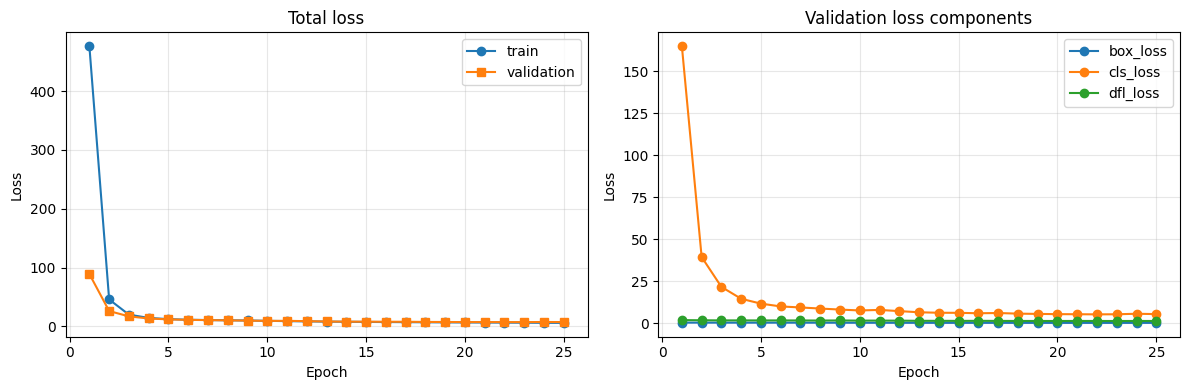

In [24]:
if DATA_AVAILABLE:
    set_seed(SEED)
    model = YOLOv8(NUM_CLASSES, REG_MAX)
    model, history = train_model(model, train_loader, val_loader, NUM_EPOCHS)
    display(history.style.format(precision=4))
    plot_history(history)
else:
    print("Bỏ qua train vì dataset chưa sẵn sàng. Model và loss đã qua smoke test ở section 9.")


## 11. Inference và NMS

Luồng xử lý: `raw outputs → DFL decode → sigmoid class scores → confidence filtering → class-aware NMS → detections`. NMS là utility được cung cấp sẵn, không phải TODO.


In [25]:
# =========================================================
# INFERENCE VÀ NMS
# =========================================================
@torch.no_grad()
def postprocess(outputs, confidence_threshold=0.25, iou_threshold=0.7, max_detections=300):
    bbox_logits, class_logits = flatten_outputs(outputs)
    anchor_points, stride_tensor = make_anchor_points(outputs)
    boxes = decode_dfl(bbox_logits, anchor_points, stride_tensor, REG_MAX)
    probabilities = class_logits.sigmoid()
    scores, labels = probabilities.max(dim=-1)
    results = []

    for image_boxes, image_scores, image_labels in zip(boxes, scores, labels):
        keep = image_scores >= confidence_threshold
        image_boxes = image_boxes[keep]
        image_scores = image_scores[keep]
        image_labels = image_labels[keep]
        if image_boxes.numel() == 0:
            results.append({
                "boxes": image_boxes.reshape(0, 4),
                "scores": image_scores,
                "labels": image_labels,
            })
            continue
        keep_indices = batched_nms(image_boxes, image_scores, image_labels, iou_threshold)
        keep_indices = keep_indices[:max_detections]
        results.append({
            "boxes": image_boxes[keep_indices],
            "scores": image_scores[keep_indices],
            "labels": image_labels[keep_indices],
        })
    return results


@torch.no_grad()
def predict_batch(model, images, confidence_threshold=0.25, iou_threshold=0.7):
    model.eval()
    outputs = model(images.to(DEVICE))
    return postprocess(outputs, confidence_threshold, iou_threshold)


## 12. Evaluation

Metric được tính sau post-processing. Với mỗi class và mỗi ngưỡng IoU, prediction được sắp theo confidence rồi ghép one-to-one với ground truth. AP là diện tích dưới precision–recall curve; mAP@0.5:0.95 lấy trung bình tại 10 ngưỡng từ 0.50 đến 0.95.


In [26]:
# =========================================================
# PRECISION, RECALL VÀ MAP
# =========================================================
def integrate_ap(recall, precision):
    mrec = np.concatenate(([0.0], recall, [1.0]))
    mpre = np.concatenate(([1.0], precision, [0.0]))
    mpre = np.flip(np.maximum.accumulate(np.flip(mpre)))
    x = np.linspace(0, 1, 101)
    y = np.interp(x, mrec, mpre)
    # np.trapz đã bị loại ở NumPy mới; fallback giữ tương thích môi trường cũ.
    return np.trapezoid(y, x) if hasattr(np, "trapezoid") else np.trapz(y, x)


def evaluate_records(records, num_classes=NUM_CLASSES):
    iou_thresholds = np.linspace(0.50, 0.95, 10)
    ap_table = np.full((num_classes, len(iou_thresholds)), np.nan)
    precision_50, recall_50 = [], []

    for class_id in range(num_classes):
        gt_by_image = {}
        predictions = []
        total_gt = 0
        for image_id, prediction, target in records:
            gt_boxes = target["boxes"][target["labels"] == class_id]
            gt_by_image[image_id] = gt_boxes
            total_gt += len(gt_boxes)
            mask = prediction["labels"] == class_id
            for box, score in zip(prediction["boxes"][mask], prediction["scores"][mask]):
                predictions.append((float(score), image_id, box))

        if total_gt == 0:
            continue
        predictions.sort(key=lambda item: item[0], reverse=True)

        for threshold_index, threshold in enumerate(iou_thresholds):
            matched = {
                image_id: torch.zeros(len(boxes), dtype=torch.bool)
                for image_id, boxes in gt_by_image.items()
            }
            true_positive, false_positive = [], []
            for _, image_id, box in predictions:
                gt_boxes = gt_by_image[image_id]
                if len(gt_boxes) == 0:
                    true_positive.append(0.0)
                    false_positive.append(1.0)
                    continue
                ious = box_iou(box.unsqueeze(0), gt_boxes).squeeze(0)
                best_iou, best_index = ious.max(dim=0)
                if best_iou >= threshold and not matched[image_id][best_index]:
                    matched[image_id][best_index] = True
                    true_positive.append(1.0)
                    false_positive.append(0.0)
                else:
                    true_positive.append(0.0)
                    false_positive.append(1.0)

            if predictions:
                tp = np.cumsum(true_positive)
                fp = np.cumsum(false_positive)
                recall_curve = tp / max(total_gt, 1)
                precision_curve = tp / np.maximum(tp + fp, 1e-9)
                ap_table[class_id, threshold_index] = integrate_ap(recall_curve, precision_curve)
                if threshold_index == 0:
                    precision_50.append(float(precision_curve[-1]))
                    recall_50.append(float(recall_curve[-1]))
            else:
                ap_table[class_id, threshold_index] = 0.0
                if threshold_index == 0:
                    precision_50.append(0.0)
                    recall_50.append(0.0)

    return {
        "Precision": float(np.mean(precision_50)) if precision_50 else float("nan"),
        "Recall": float(np.mean(recall_50)) if recall_50 else float("nan"),
        "mAP@0.5": float(np.nanmean(ap_table[:, 0])),
        "mAP@0.5:0.95": float(np.nanmean(ap_table)),
    }


@torch.no_grad()
def evaluate_model(model, loader, confidence_threshold=0.001, iou_threshold=0.7):
    model.eval()
    records = []
    image_id = 0
    for images, targets in tqdm(loader, leave=False):
        predictions = predict_batch(model, images, confidence_threshold, iou_threshold)
        for prediction, target in zip(predictions, targets):
            target_boxes = xywhn_to_xyxy(target["boxes"], images.shape[-1]).cpu()
            target_cpu = {"boxes": target_boxes, "labels": target["labels"].cpu()}
            prediction_cpu = {key: value.cpu() for key, value in prediction.items()}
            records.append((image_id, prediction_cpu, target_cpu))
            image_id += 1
    return pd.DataFrame([evaluate_records(records)])


In [27]:
if DATA_AVAILABLE:
    metrics = evaluate_model(model, val_loader)
    display(metrics.style.format(precision=4))
else:
    print("Bỏ qua evaluation vì dataset chưa sẵn sàng.")


  0%|          | 0/51 [00:00<?, ?it/s]

,Precision,Recall,mAP@0.5,mAP@0.5:0.95
0,0.0550,0.6209,0.2038,0.0821


## 13. Visualization predictions


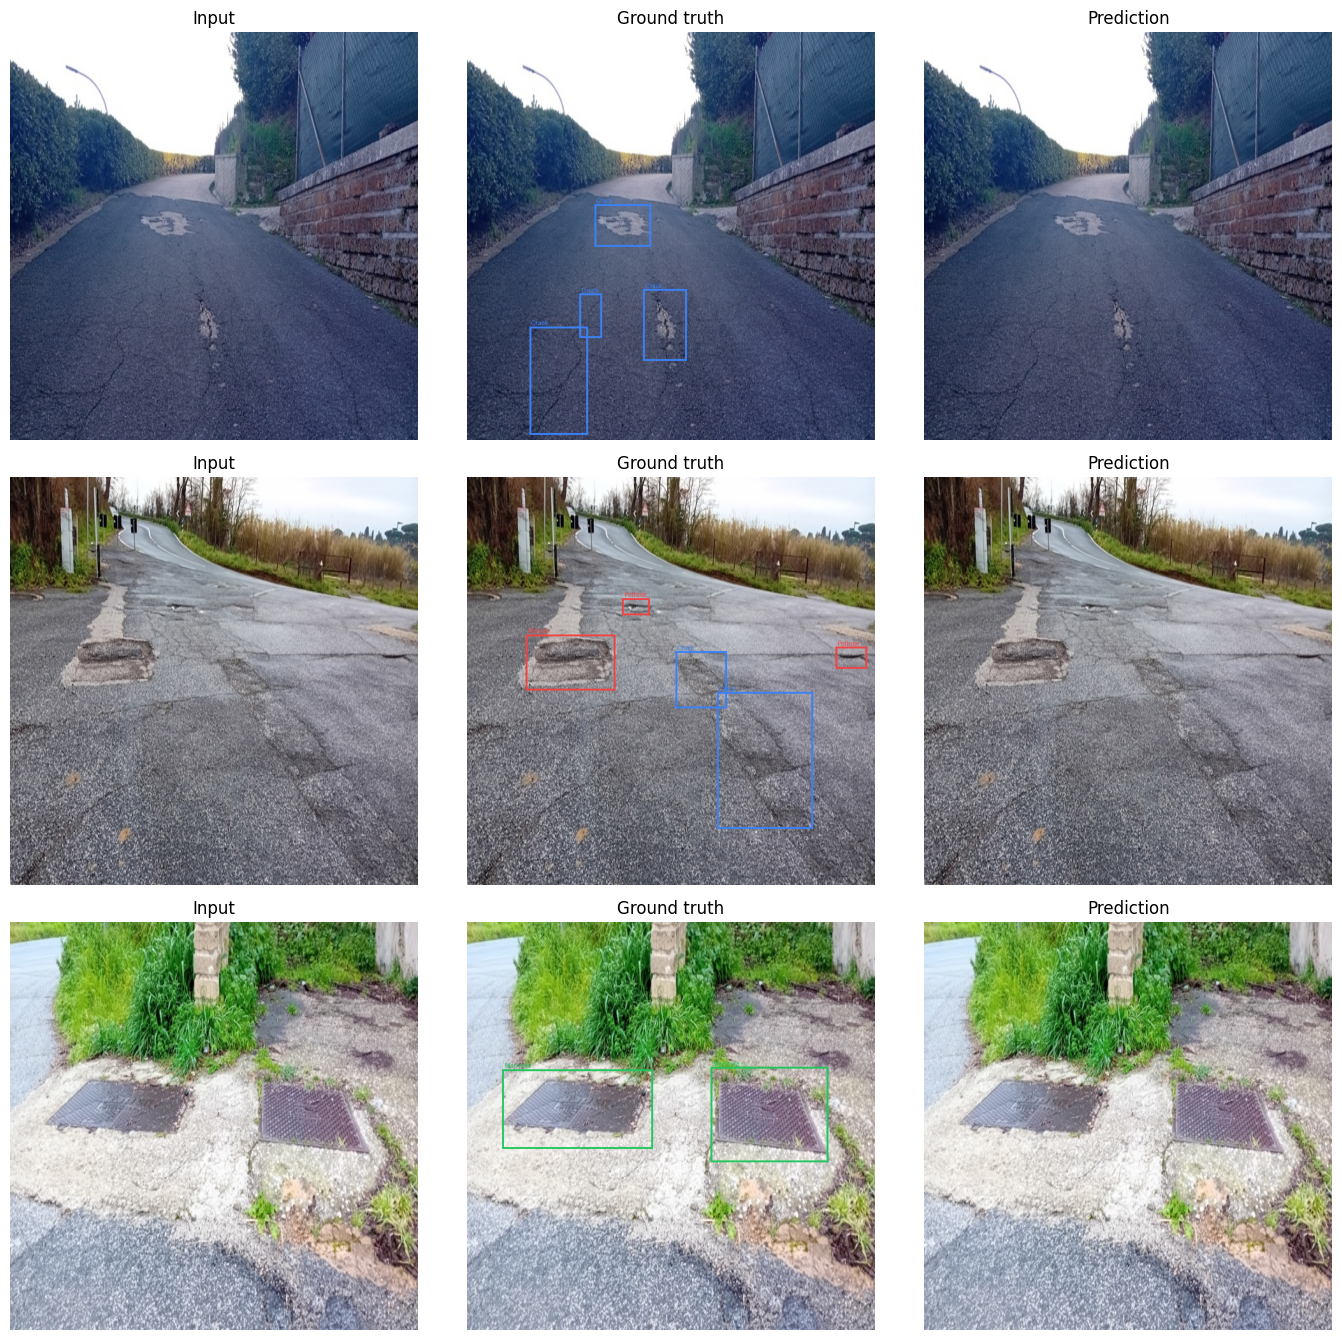

In [28]:
# =========================================================
# TRỰC QUAN HÓA INPUT / GROUND TRUTH / PREDICTION
# =========================================================
@torch.no_grad()
def visualize_predictions(model, dataset, count=3, confidence_threshold=0.25):
    count = min(count, len(dataset))
    fig, axes = plt.subplots(count, 3, figsize=(14, 4.5 * count), squeeze=False)

    for row in range(count):
        image, target = dataset[row]
        prediction = predict_batch(
            model, image.unsqueeze(0), confidence_threshold=confidence_threshold
        )[0]
        gt_boxes = xywhn_to_xyxy(target["boxes"], image.shape[-1])

        axes[row, 0].imshow(TF.to_pil_image(image))
        axes[row, 0].set_title("Input")
        axes[row, 1].imshow(draw_boxes(image, gt_boxes, target["labels"]))
        axes[row, 1].set_title("Ground truth")
        axes[row, 2].imshow(draw_boxes(
            image, prediction["boxes"].cpu(), prediction["labels"].cpu(),
            prediction["scores"].cpu(),
        ))
        axes[row, 2].set_title("Prediction")
        for axis in axes[row]:
            axis.axis("off")

    plt.tight_layout()
    plt.show()


if DATA_AVAILABLE:
    visualize_predictions(model, val_dataset, count=3)
else:
    print("Bỏ qua visualization predictions vì dataset chưa sẵn sàng.")


## 14. Câu hỏi & kết luận

> Phân tích vai trò của Backbone, Multi-scale Feature Fusion và Detection Head trong YOLOv8. Giải thích vì sao dự đoán trên P3, P4, P5 giúp phát hiện các đối tượng có kích thước khác nhau. Nêu điểm khác biệt chính giữa cơ chế anchor-free của YOLOv8 và cơ chế anchor-based của các phiên bản YOLO trước.

**Trả lời của bạn:**

...
